Machine Learning Model

Initializes the beginning of the code

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

dataRates = [
    "Stock is soaring through the roof",
    "Stock is having a continued increase",
    "Stock is having a marginal increase",
    "Stock is staying around the same as yesterdays closing period",
    "Stock is decreasing slightly",
    "Stock is substantially decreasing",
    "Stock is having a record drop"
]

dataStats = [1, 1, 1, 0, 0, 0, 0]

ratesHeadlines = pd.DataFrame({"headline": dataRates})

statsLabel = pd.DataFrame({"label": dataStats})

headlinesTrain, headlinesTest, labelTrain, labelTest = train_test_split(ratesHeadlines["headline"], statsLabel["label"], test_size=0.33, random_state=42)


vectorizer = TfidfVectorizer()
headlineTrainVec = vectorizer.fit_transform(headlinesTrain)
headlineTestVec = vectorizer.transform(headlinesTest)

headlineModel = LogisticRegression(random_state=42).fit(headlineTrainVec, labelTrain)

headlinePredict = headlineModel.predict(headlineTestVec)

accuracyHeadline = accuracy_score(labelTest, headlinePredict)
print(f"Model Accuracy: {accuracyHeadline}")

print(classification_report(labelTest, headlinePredict, target_names=["Positive","Negative"]))


Model Accuracy: 0.3333333333333333
              precision    recall  f1-score   support

    Positive       0.33      1.00      0.50         1
    Negative       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

Trains a list of values to predict the possible rates

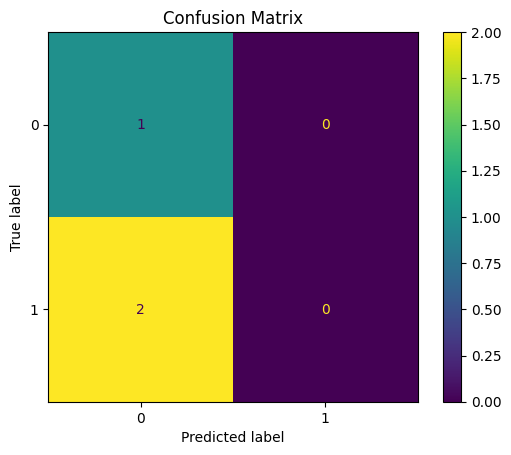

[ 0 15 13  9 16 14  7  5  6  8]
[ 3 12 10  4  2 11  1  0 15 13]


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.svm import SVC

dataRates = [
    "Stock is soaring through the roof",
    "Stock is having a continued increase",
    "Stock is having a marginal increase",
    "Stock is staying around the same as yesterdays closing period",
    "Stock is decreasing slightly",
    "Stock is substantially decreasing",
    "Stock is having a record drop"
]

dataStats = [1, 1, 1, 0, 0, 0, 0]

ratesHeadlines = pd.DataFrame({"headline": dataRates})

statsLabel = pd.DataFrame({"label": dataStats})

headlinesTrain, headlinesTest, labelTrain, labelTest = train_test_split(ratesHeadlines["headline"], statsLabel["label"], test_size=0.33, random_state=42)


vectorizer = TfidfVectorizer()
headlineTrainVec = vectorizer.fit_transform(headlinesTrain)
headlineTestVec = vectorizer.transform(headlinesTest)

headlineModel = LogisticRegression(random_state=42).fit(headlineTrainVec, labelTrain)


clf = SVC(random_state=42)
clf.fit(headlineTrainVec, labelTrain)

predictions = clf.predict(headlineTestVec)

cm = confusion_matrix(labelTest, predictions)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

learnedCoef = headlineModel.coef_[0]

sortLearnCoef = np.argsort(learnedCoef)

max5LearnCoef = sortLearnCoef[len(sortLearnCoef) - 10: len(sortLearnCoef)]
min5LearnCoef = sortLearnCoef[:10]

print(max5LearnCoef)
print(min5LearnCoef)

Trains a list of new values

In [7]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

newRates = [
    "Stock rises and falls",
    "Stock falls as controvery pursues",
    "Stocks takes an upheaval from yesterday as it soars"
]

newStatsRates = [0, 0, 1]

newHeadlines = pd.DataFrame({"headline":newRates})

newLabel = pd.DataFrame({"label":newStatsRates})

newHeadlinesTrain, newHeadlinesTest, newLabelTrain, newLabelTest = train_test_split(newHeadlines, newLabel, test_size=0.33, random_state=42)

vectorizer = TfidfVectorizer()
newLineTrainVec = vectorizer.fit_transform(newHeadlinesTrain["headline"])
newLineTestVec = vectorizer.transform(newHeadlinesTest["headline"])

newHeadlineModel = LogisticRegression(random_state=42).fit(newLineTrainVec, newLabelTrain)

headlineTestPredict = newHeadlineModel.predict(newLineTestVec)

newAccuracyHeadline = accuracy_score(newLabelTest, headlineTestPredict)
print(f"Model Accuracy: {newAccuracyHeadline}")

new_text = ["This is a terrible stock."]
new_text_vec = vectorizer.transform(new_text)
predicted_sentiment = newHeadlineModel.predict(new_text_vec)


print(headlineTestPredict)
print(new_text_vec)
print(predicted_sentiment)

Model Accuracy: 1.0
[0]
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1 stored elements and shape (1, 13)>
  Coords	Values
  (0, 8)	1.0
[0]


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Graphing stock strategy

C:\Users\matth\AppData\Local\Temp\ipykernel_34552\1528416877.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2015-01-01", end="2023-12-01", progress=False)


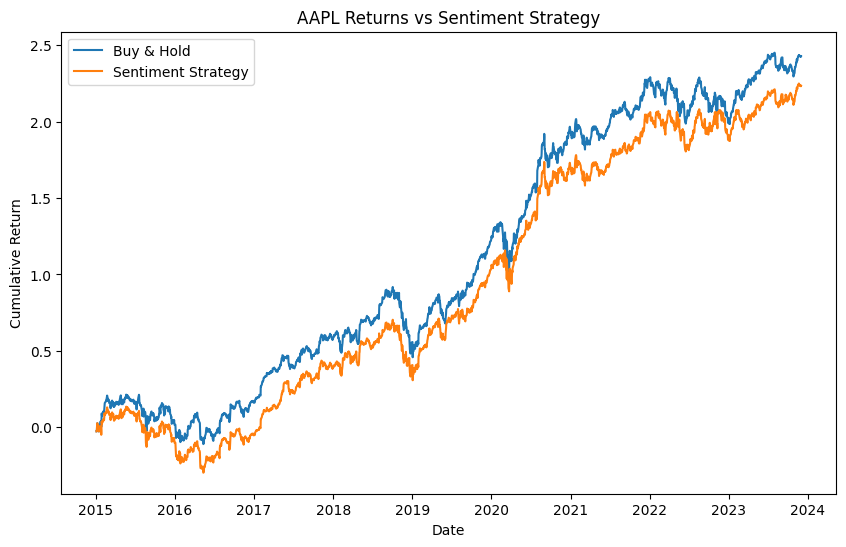

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

stock = yf.download("AAPL", start="2015-01-01", end="2023-12-01", progress=False)

# Make sure we have usable data
if stock.empty:
    raise ValueError("No stock data found. Try another ticker or date range.")

# Choose adjusted close if available
close_col = "Adj Close" if "Adj Close" in stock.columns else "Close"

stock["Return"] = stock[close_col].pct_change()
stock["CumulativeReturn"] = stock["Return"].cumsum()


num_signals = len(stock) // 10   # pretend we only have signals for some days
signals = pd.Series(np.random.choice([0, 1], size=num_signals))

random_dates = np.random.choice(stock.index, size=num_signals, replace=False)
signals.index = random_dates
signals = signals.sort_index()

strategy_returns = stock["Return"].copy()
strategy_returns.loc[signals.index] = strategy_returns.loc[signals.index] * (2*signals - 1)

stock["StrategyCumulative"] = strategy_returns.cumsum()


plt.figure(figsize=(10,6))
plt.plot(stock.index, stock["CumulativeReturn"], label="Buy & Hold")
plt.plot(stock.index, stock["StrategyCumulative"], label="Sentiment Strategy")
plt.title("AAPL Returns vs Sentiment Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()